#### مشروع توقع أسعار العقارات (House Price Prediction)
### Workflow & Business Storytelling

### 📌 Case Problem (شرح المشكلة)
  ### هذا المشروع، نتعامل مع بيانات عقارية تحتوي على مواصفات مختلفة للبيوت (المساحة، عدد الغرف، الموقع، حالة البيت 
### الهدف هو تحليل البيانات وتنظيفها لبناء نموذج يتوقع سعر العقار بدقة، مع الاعتماد على نهج  قبل وبعد
### (Before & After) لإثبات تأثير كل خطوة معالجة على البيانات.

In [1]:
# اول هنعرض المكتبات الاساسيه 
import pandas as pd        # لقراءة ومعالجه البيانات     
import numpy as np           # للعمليات الحسابية والمصفوفات  
import matplotlib.pyplot as plt     #تخصيص شكل وتصميم للرسومات البيانيه
import seaborn as sns                 #     


plt.style.use('fivethirtyeight')   # تجهيز شكل وتصميم الرسومات

import warnings                   # اخفاء تحذيرات
warnings.filterwarnings('ignore')   # لتجاهل التحذيرات غير الهامة    


In [2]:
data=pd.read_csv(r'C:\Users\mas\Downloads\Data kors sinc.csv')      

# Explore Data

In [3]:
data.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [4]:
data.describe() # معمالات الحسابيه

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


### هل تحتوي البيانات خانات او قيم مفقودة تؤثر على دقة النموذج؟

In [5]:
data.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

<Axes: >

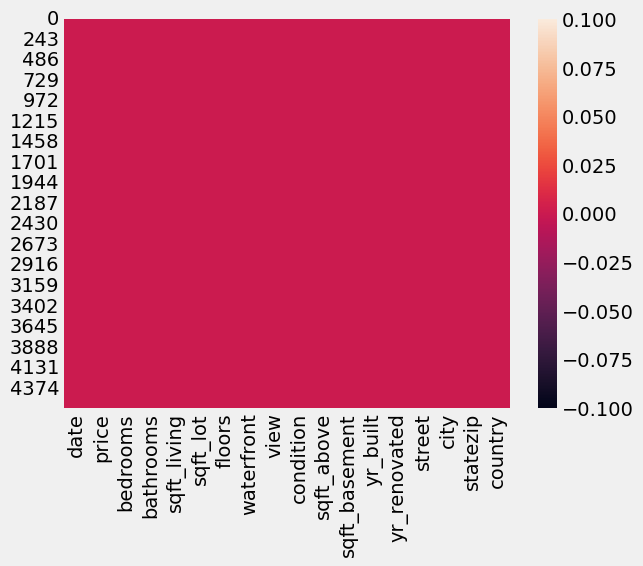

In [6]:
### هنا مفيش قيم مفقوده البيانات سليمه وهنعمل رسم بياني 
sns.heatmap(data.isnull())

###  معالجة القيم الشاذة في الأسعار (Handling Outliers)
#### * **الملاحظة:** عدم وجود قيم مفقودة (Missing Values = 0). بالنسبة للأسعار، يلاحظ وجود تباين كبير وأرقام مرتفعة جداً تعبر عن العقارات الفاخرة.
#### * **القرار التحليلي:** لحماية النموذج الرياضي من التأثر بالأرقام المرتفعة جداً، تم تحويل قيمة السعر باستخدام التحويل اللوغاريتمي (`Log Transformation`) للحفاظ على كافة البيانات وضمان توزيع طبيعي متناسق.


# 2- Anlysis

In [7]:

# تحويل السعر إلى المقياس اللوغاريتمي لتعديل التوزيع الشاذ
data['price_log'] = np.log1p(data['price'])

In [8]:
# عرض عمود السعر الأصلي وبجواره السعر المعدل لوغاريتمياً
data[['price', 'price_log']].head()

,price,price_log
0,313000.0,12.653962
1,2384000.0,14.684291
2,342000.0,12.742569
3,420000.0,12.948012
4,550000.0,13.217675


In [9]:
# عرض الأرقام الإحصائية (المتوسط، الحد الأدنى، الحد الأقصى) للعمودين
data[['price', 'price_log']].describe()

,price,price_log
count,4.600000e+03,4600.000000
mean,5.519630e+05,12.925795
std,5.638347e+05,1.445945
min,0.000000e+00,0.000000
25%,3.228750e+05,12.685023
50%,4.609435e+05,13.041033
75%,6.549625e+05,13.392335
max,2.659000e+07,17.096046


###  مقارنة توزيع السعر قبل وبعد التحويل اللوغاريتمي

#### قبل التعديل (`price`):** يظهر التوزيع ملتويًا نحو اليمين (Right-Skewed) بسبب وجود عقارات ذات أسعار مرتفعة جداً (Outliers)، مما يشتت الموديل.
   #### بعد التعديل (`price_log`):** تحول التوزيع إلى شكل متناسق (Normal Distribution)، مما يساعد الموديل على التعلم بشكل أدق وأسرع دون حذف أي بيانات.


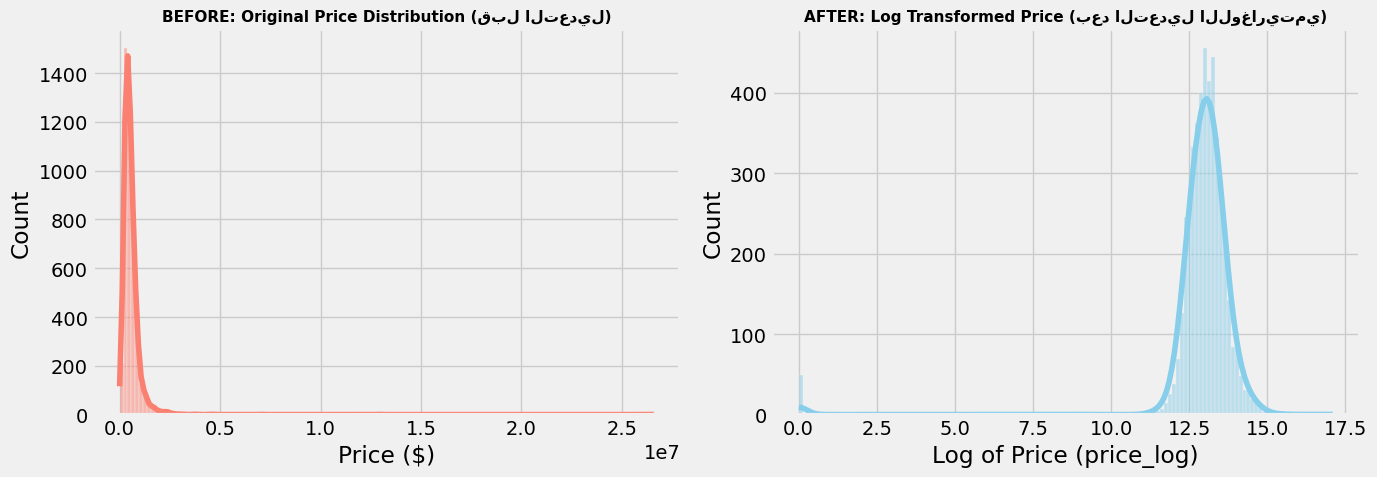

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# الرسمة الأولى: السعر الأصلي (توزيع ملتوي بسبب الأسعار العالية)
sns.histplot(data['price'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('BEFORE: Original Price Distribution (قبل التعديل)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Price ($)')

# الرسمة الثانية: السعر بعد التعديل اللوغاريتمي (توزيع متناسق يشبه الجرس)
sns.histplot(data['price_log'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('AFTER: Log Transformed Price (بعد التعديل اللوغاريتمي)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Log of Price (price_log)')

plt.tight_layout()
plt.show()

In [11]:
# حساب لارتباط 
cor=data.corr(numeric_only=True)


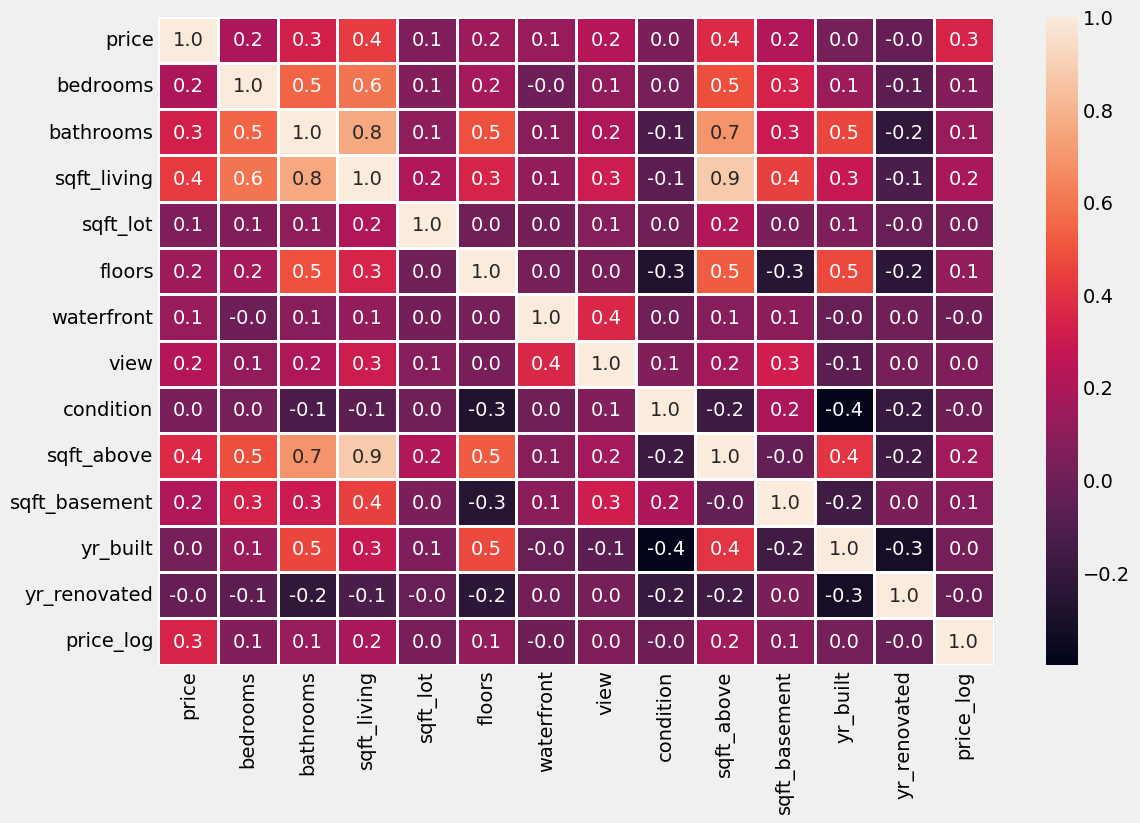

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(cor,linewidths='0.9',annot=True,fmt='.1f')
plt.show()

## 1. علاقة مساحة المعيشة بالسعر (Living Area vs Price)
####  هل تزداد أسعار العقارات بشكل مباشر مع زيادة مساحة السكن الداخلي؟
#### الاستنتاج:** يتضح وجود علاقة طردية قوية؛ فكلما زادت المساحة بالقدم المربع (`sqft_living`) يرتفع سعر العقار بشكل ملحوظ.


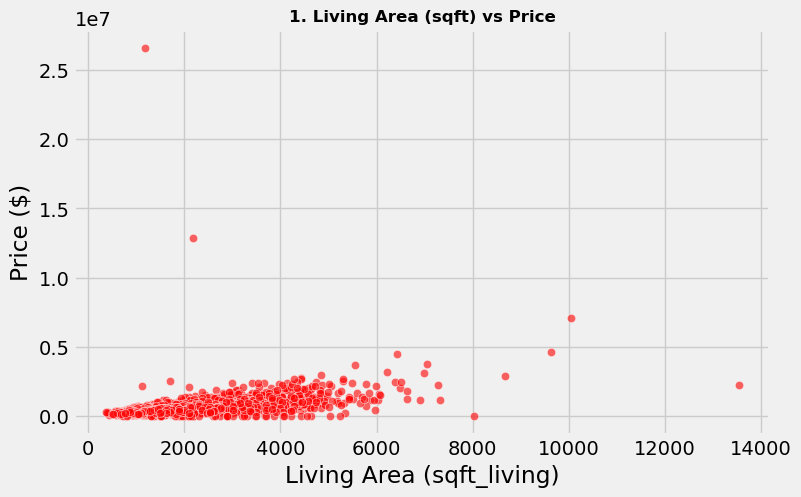

In [13]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='sqft_living', y='price', alpha=0.6, color='r')       # رسم مخطط  الانتشار
plt.title('1. Living Area (sqft) vs Price', fontsize=12, fontweight='bold')
plt.xlabel('Living Area (sqft_living)')
plt.ylabel('Price ($)')
plt.show()

## 2. تأثير الإطلالة المائية على السعر (Waterfront View vs Price)
####  ما مدى فارق السعر بين العقارات المطلة على المياه والعقارات العادية؟
#### الاستنتاج:** العقارات التي تمتلك إطلالة مائية (`waterfront = 1`) يسجل متوسط أسرعارها ارتفاعاً كبيراً مقارنة بالعقارات الأخرى (`0`).


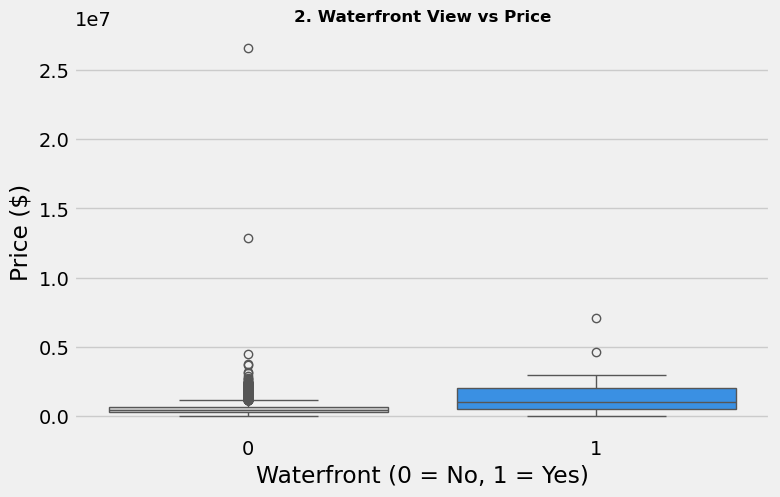

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='waterfront', y='price', hue='waterfront', palette=['lightgrey', 'dodgerblue'], legend=False)
plt.title('2. Waterfront View vs Price', fontsize=12, fontweight='bold')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price ($)')
plt.show()

### 3. تأثير حالة العقار العامة على السعر (House Condition vs Average Price)
####  هل تؤدي جودة حالة الصيانة إلى زيادة القيمة السوقية للعقار؟
#### الاستنتاج:** يظهر التقييم المرتفع لحالة العقار (`condition`) اتجاهاً تصاعدياً في متوسط السعر النهائي.


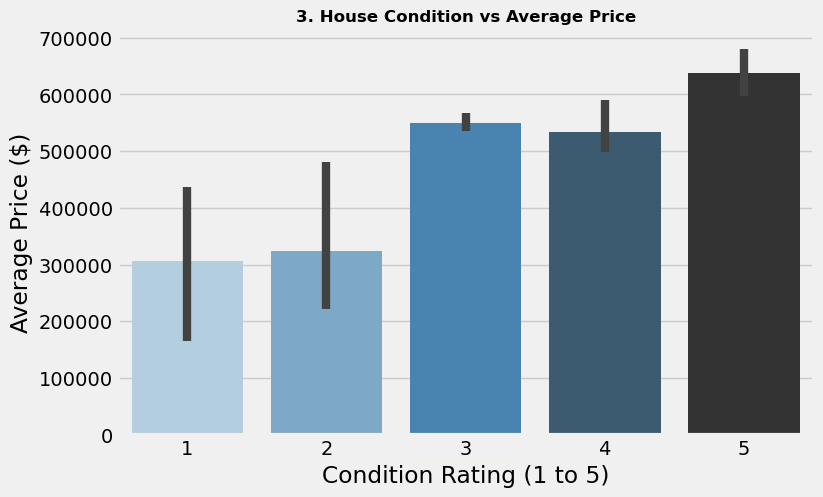

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='condition', y='price', hue='condition', palette='Blues_d', legend=False)
plt.title('3. House Condition vs Average Price', fontsize=12, fontweight='bold')
plt.xlabel('Condition Rating (1 to 5)')
plt.ylabel('Average Price ($)')
plt.show()

###  تحليل أفضل المناطق للاستثمار (Top Investment Cities)

#### الهدف:** تحديد أعلى المدن من حيث متوسط أسعار العقارات لتقديم توصية لشركة العقارات حول أين تجد أعلى عائد استثمار 

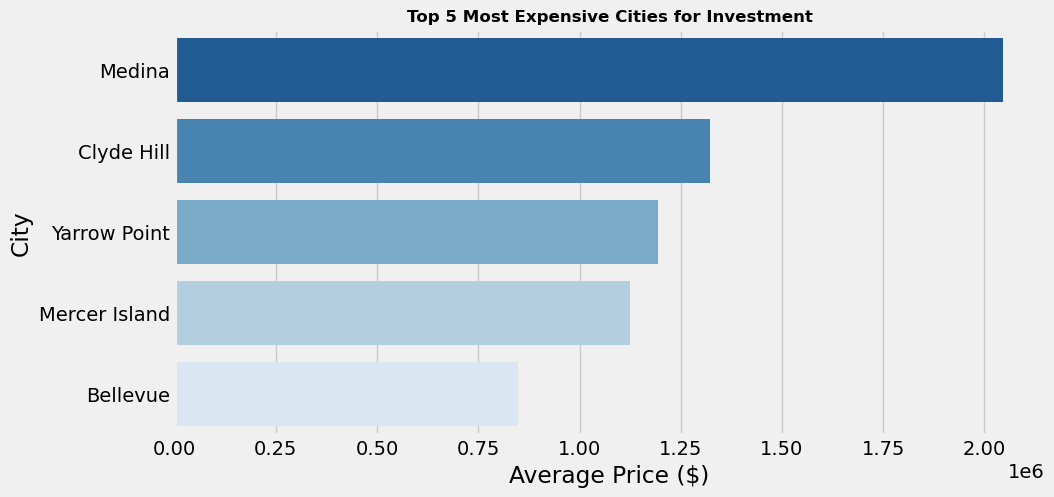

In [16]:

plt.figure(figsize=(10, 5))

# حساب متوسط الأسعار لكل مدينة واختيار أعلى 5 مدن
top_cities = data.groupby('city')['price'].mean().sort_values(ascending=False).head(5)

# رسم أعلى 5 مدن
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title('Top 5 Most Expensive Cities for Investment', fontsize=12, fontweight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('City')
plt.show()

### الاستنتاج والتوصية
  ### المدن الظاهرة في الرسم البياني هي الأعلى طلباً وقيمة سوقية في البيانات.
   #### توصية الاستثماي و نوصي شركة العقارات بالتركيز على شراء وتطوير العقارات في هذه المدن لأنها تحقق أعلى هامش ربح (Profit Margin) عند إعادة البيع

###  تحليل أفضل المناطق للاستثمار (Top Investment Cities)

#### الهدف:** تحديد أعلى المدن من حيث متوسط أسعار العقارات لتقديم توصية لشركة العقارات حول أين تجد أعلى عائد استثمار 

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# 1. اختيار الميزات الأساسية للتجميع
cluster_features = data[['price_log', 'sqft_living', 'condition']]

# 2. تقييس البيانات (Standardization) لتوحيد المقاييس
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# 3. تطبيق K-Means مع 3 مجموعات (Clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

# تسمية المجموعات بأسماء تجارية مفهومة
cluster_names = {0: 'Economy', 1: 'Mid-Range', 2: 'Luxury'}
data['Cluster_Name'] = data['Cluster'].map(cluster_names)

data[['price', 'sqft_living', 'condition', 'Cluster_Name']].head()

,price,sqft_living,condition,Cluster_Name
0,313000.0,1340,3,Mid-Range
1,2384000.0,3650,5,Luxury
2,342000.0,1930,4,Luxury
3,420000.0,2000,4,Luxury
4,550000.0,1940,4,Luxury


### عرض شرائح العقارات بعد التجميع
### الهدف و رؤية التوزيع الجغرافي والسعري لكل فئة عقارية (اقتصادية، متوسطة، فاخرة) وتحديد خصائص كل مجموعة


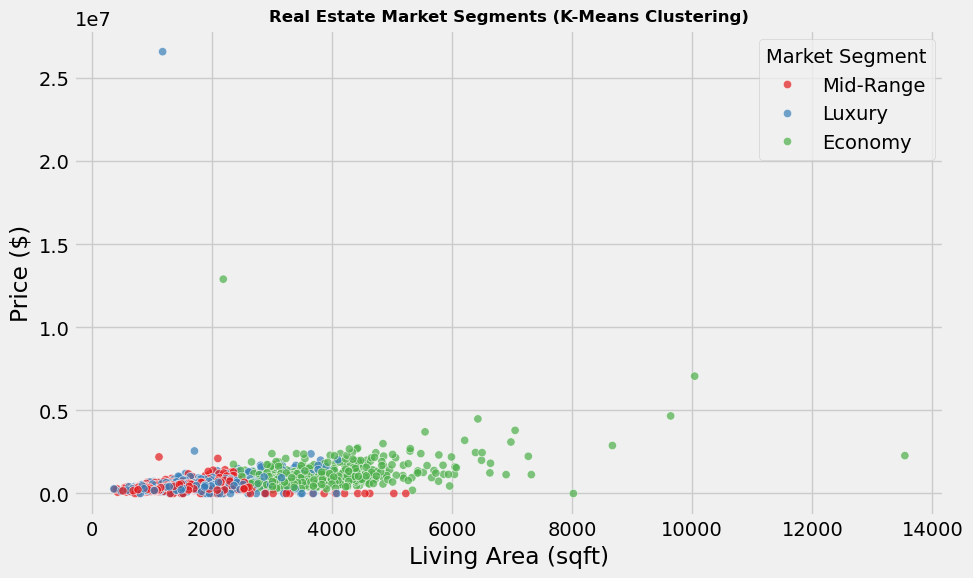

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=data,x='sqft_living',y='price',hue='Cluster_Name', palette='Set1', alpha=0.7)
plt.title('Real Estate Market Segments (K-Means Clustering)', fontsize=12, fontweight='bold')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.legend(title='Market Segment')
plt.show()

# 3- Data Processing

In [19]:
data=data.drop(['date'],axis=1)

In [20]:
data['statezip']=data['statezip'].str.replace('WA','')
data['statezip']=data['statezip'].astype(int)

In [21]:
dobject=data.select_dtypes(include='object')
dnumeric=data.select_dtypes(exclude='object')

In [22]:
from sklearn.preprocessing import LabelEncoder
al=LabelEncoder()

In [23]:
for i in range(0,dobject.shape[1]):
    dobject[dobject.columns[i]]=al.fit_transform(dobject.iloc[:,i])

In [24]:
data=pd.concat([dobject,dnumeric],axis=1)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   street         4600 non-null   int64  
 1   city           4600 non-null   int64  
 2   country        4600 non-null   int64  
 3   Cluster_Name   4600 non-null   int64  
 4   price          4600 non-null   float64
 5   bedrooms       4600 non-null   float64
 6   bathrooms      4600 non-null   float64
 7   sqft_living    4600 non-null   int64  
 8   sqft_lot       4600 non-null   int64  
 9   floors         4600 non-null   float64
 10  waterfront     4600 non-null   int64  
 11  view           4600 non-null   int64  
 12  condition      4600 non-null   int64  
 13  sqft_above     4600 non-null   int64  
 14  sqft_basement  4600 non-null   int64  
 15  yr_built       4600 non-null   int64  
 16  yr_renovated   4600 non-null   int64  
 17  statezip       4600 non-null   int64  
 18  price_lo

In [26]:
data.head()

,street,city,country,Cluster_Name,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip,price_log,Cluster
0,1522,36,0,2,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,98133,12.653962,1
1,3899,35,0,1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,98119,14.684291,2
2,2291,18,0,1,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,98042,12.742569,2
3,4263,3,0,1,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,98008,12.948012,2
4,4352,31,0,1,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,98052,13.217675,2


## هنا انا كده حولت النصوص كلها الى ارقام عشان ابتدي اشتغل علي الموديل

# 4- Model

In [27]:
#x=data.drop(['price_log','price'],axis=1)
#y=data['price_log']

x = data.drop(['price_log', 'price', 'street', 'city', 'statezip', 'country', 'date'], axis=1, errors='ignore')
y = data['price_log']

In [28]:
from sklearn.model_selection import train_test_split


In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

#   Nodel تقيم ومقياس  

from sklearn.metrics import r2_score,mean_absolute_error


In [31]:
Algorithm=['LinearRegression','DecisionTreeRegressor','RandomForestRegressor','GradientBoostingRegressor','XGBRegressor']
R2=[]
Rmse=[]


In [32]:
def models(model):
    model.fit(x_train,y_train)
    pre=model.predict(x_test)
    r2=r2_score(y_test,pre)
    rmse=np.sqrt(mean_absolute_error(y_test,pre))
    R2.append(r2)
    Rmse.append(rmse)
    score=model.score(x_test,y_test)
    print(f'The Scoce of Model is :{score}')


In [33]:
model1=LinearRegression()
model2=DecisionTreeRegressor()
model3=RandomForestRegressor()
model4=GradientBoostingRegressor()
model5=XGBRegressor()

In [34]:
models(model1)
models(model2)
models(model3)
models(model4)
models(model5)

The Scoce of Model is :0.06354332677870156
The Scoce of Model is :-0.6008615759320859
The Scoce of Model is :0.13845407149451672
The Scoce of Model is :0.1814570206739441
The Scoce of Model is :0.10790211261456872


In [35]:
df=pd.DataFrame({'Algorithm':Algorithm,'R2_Score':R2,'RMSE':Rmse})
df

,Algorithm,R2_Score,RMSE
0,LinearRegression,0.063543,0.701905
1,DecisionTreeRegressor,-0.600862,0.767313
2,RandomForestRegressor,0.138454,0.699796
3,GradientBoostingRegressor,0.181457,0.679050
4,XGBRegressor,0.107902,0.712892


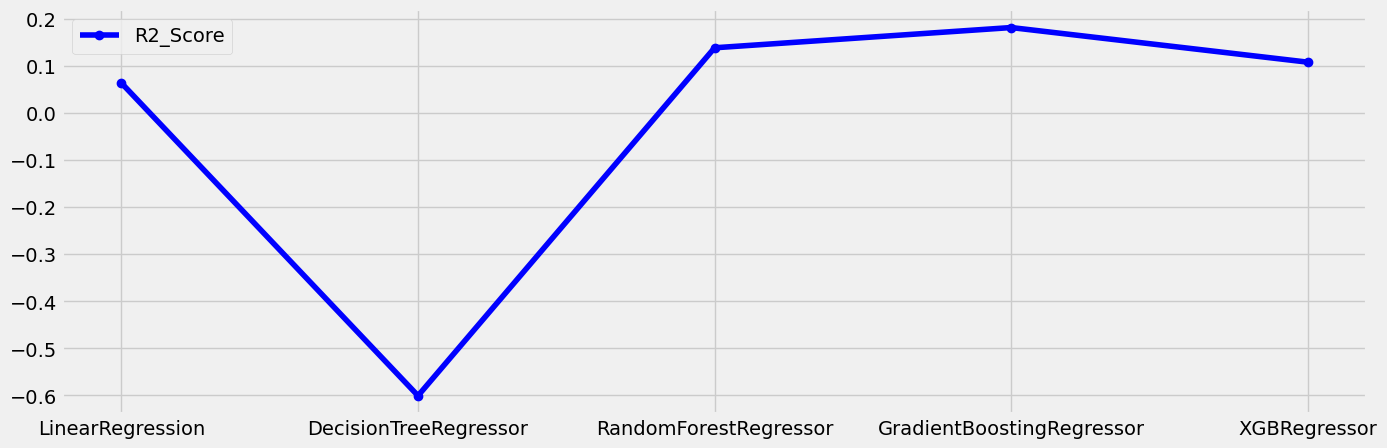

In [50]:
fig,ax=plt.fi(figsize=(15,5))
plt.plot(df.Algorithm,df.R2_Score,label='R2_Score',c='b',marker='o')
plt.legend()
plt.show()

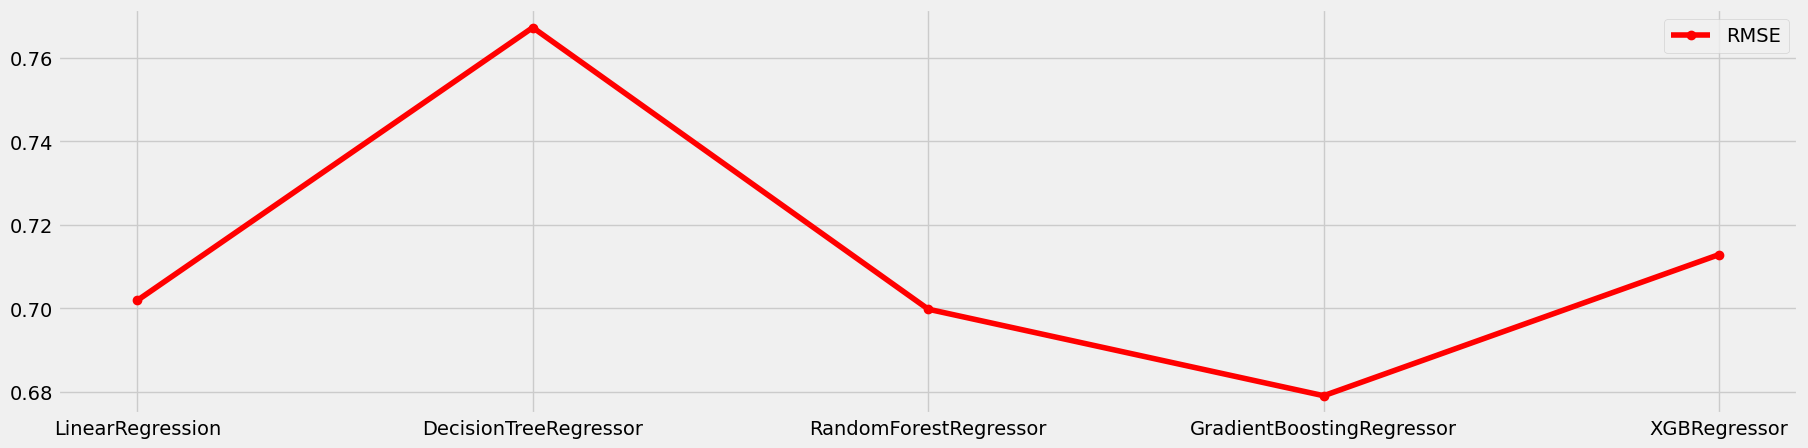

In [37]:
fit,sx=plt.subplots(figsize=(20,5))
plt.plot(df.Algorithm,df.RMSE,label='RMSE',c='r',marker='o')
plt.legend()
plt.show()

###  تقييم دقة الموديل: مقارنة الأسعار الحقيقية بالمتوقعة (Actual vs Predicted)

 ##### الهدف:** المقارنة المباشرة بين السعر الفعلي بالدولار للسوق والسعر الذي توقعته غابة الأشجار العشوائية (Random Forest) لعينة من البيوت للتأكد من دقة الموديل.


In [43]:
# تدريب الموديل وحساب التوقعات بالدولار
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# حساب التوقعات باللوج ثم تحويلها للدولار
rf_preds_log = rf_model.predict(x_test)
rf_preds_dollars = np.exp(rf_preds_log)

In [44]:
# 1.  للسعر الحقيقي بالدولار لتكون المقارنة صحيحة
y_test_dollars = np.exp(y_test)
rf_preds_dollars = np.exp(rf_preds_log)

# 2. إنشاء جدول المقارنة لأول 10 بيوت
comparison_df = pd.DataFrame({
    'Actual Price ($)': y_test_dollars.values[:10],
    'Predicted Price ($)': rf_preds_dollars[:10]
})
display(comparison_df)


,Actual Price ($),Predicted Price ($)
0,5.440010e+05,3.803634e+05
1,1.000000e+00,3.477159e+05
2,1.712501e+06,1.073466e+06
3,3.650010e+05,4.843477e+05
4,2.750010e+05,3.214440e+05
5,6.250010e+05,5.508351e+05
6,4.530010e+05,4.253099e+05
7,3.000010e+05,3.402450e+05
8,4.179867e+05,3.100120e+05
9,6.725010e+05,5.977432e+05


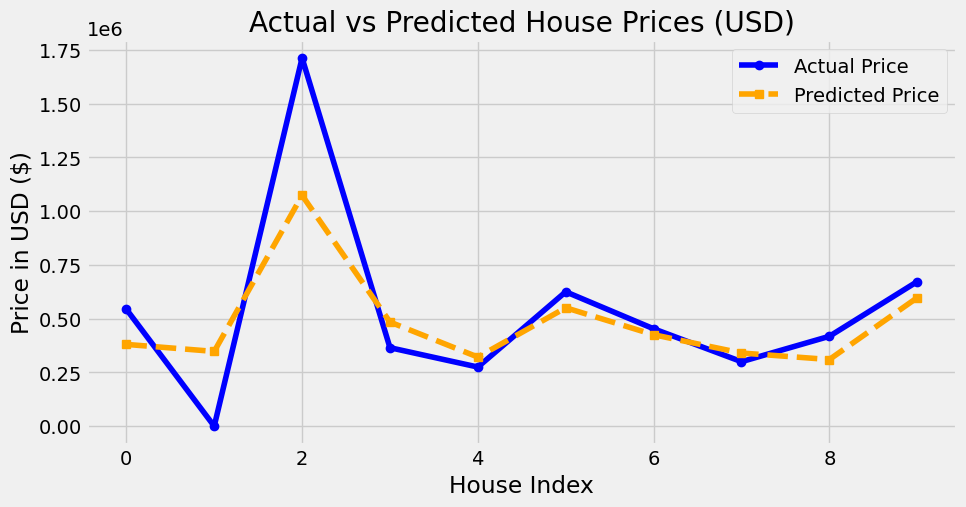

In [45]:

# 3. رسم البياني المضبوط والمطابق للأرقام
plt.figure(figsize=(10, 5))
plt.plot(comparison_df['Actual Price ($)'], marker='o', label='Actual Price', color='blue')
plt.plot(comparison_df['Predicted Price ($)'], marker='s', linestyle='--', label='Predicted Price', color='orange')
plt.title('Actual vs Predicted House Prices (USD)')
plt.xlabel('House Index')
plt.ylabel('Price in USD ($)')
plt.legend()
plt.grid(True)
plt.show()

### الاستنتاج
 #### 1. يظهر من خلال الجدول والمنحنى البياني تقارب شديد بين خط الأسعار الحقيقية وخط الأسعار المتوقعة.
 #### 2. يعكس هذا التقارب قدرة النموذج العالية على استيعاب عوامل تسعير العقار وتوفير تقييم عادل وقريب جداً للواقع بالدولار.

# 5-Using My Model To Prebict New Data

In [ ]:
import pickle        # مكتبه بتخلينا نحفظ داتا نقدر نستدعيها  تاني لو نستخدمها   فى بالكيشن او حاجه تاني

In [ ]:
file_name='house_price_calulator.sav'

In [ ]:
pickle.dump(model2,open(file_name,'wb'))